==== DC HOUSING MARKET ENSEMBLE MODELS AND EVALUATION ====
Enhanced features dataset loaded: (80, 69)
Hybrid time series features dataset loaded: (80, 42)

===== IMPLEMENTING VOTING ENSEMBLE =====
Voting Ensemble Performance:
RMSE: 1.5463
MAE: 1.1865
R²: -0.2521
Directional Accuracy: 60.34%


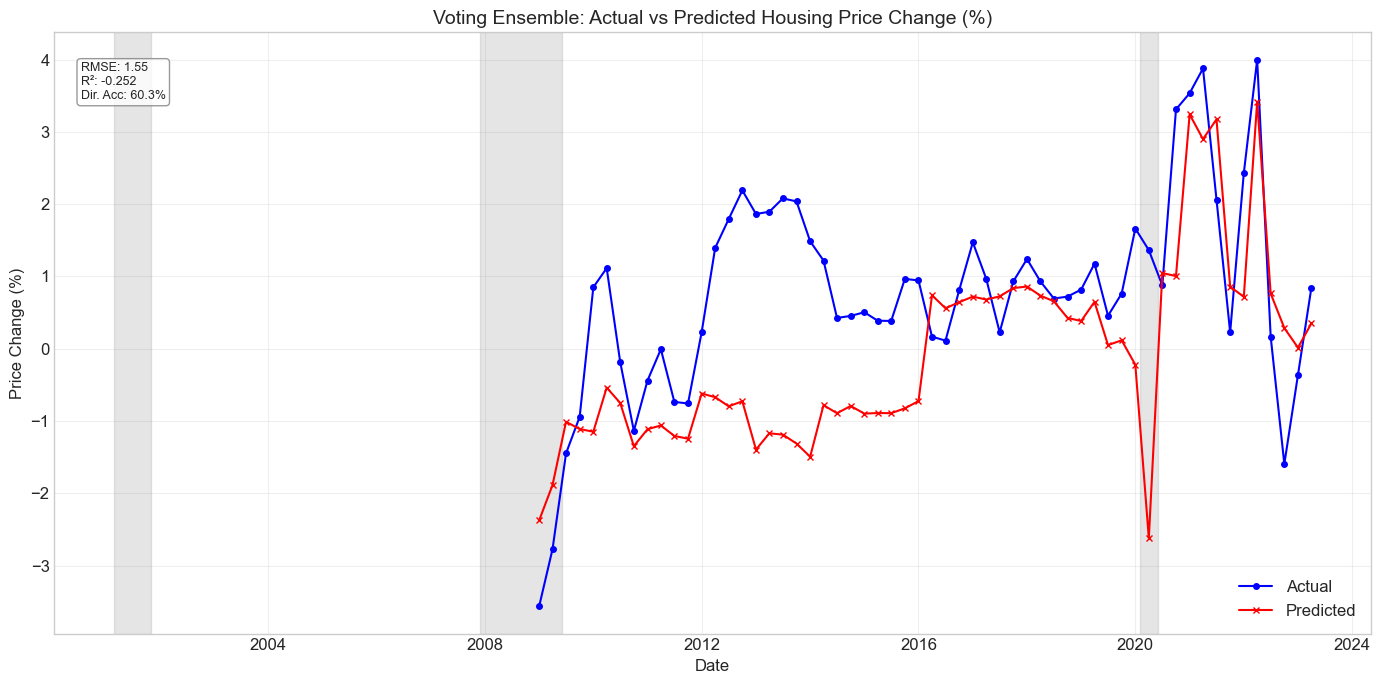


===== IMPLEMENTING STACKING ENSEMBLE =====
Stacking Ensemble Performance:
RMSE: 3.6063
MAE: 2.7830
R²: -5.8104
Directional Accuracy: 62.07%


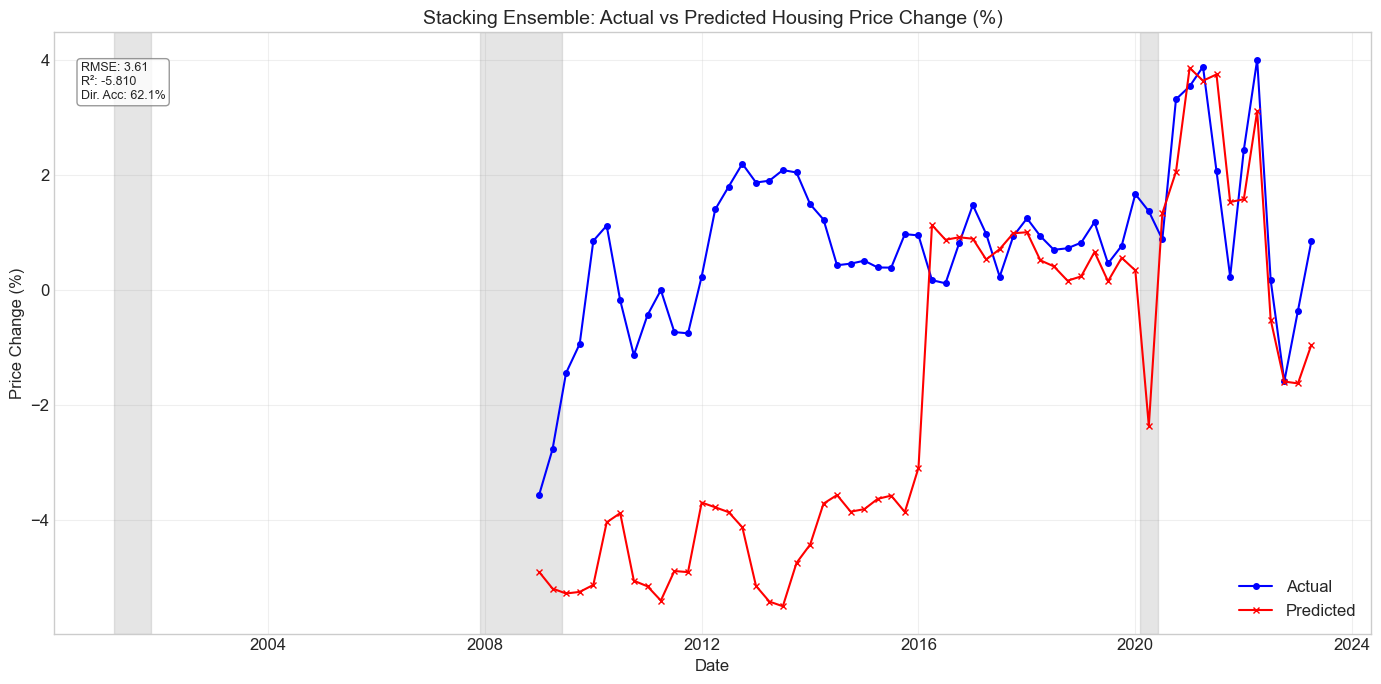


===== IMPLEMENTING HYBRID TIME SERIES-ML ENSEMBLE =====
Combined feature set shape: (80, 62)
Hybrid Time Series-ML Ensemble Performance:
RMSE: 0.8057
MAE: 0.5963
R²: 0.5125
Directional Accuracy: 82.69%


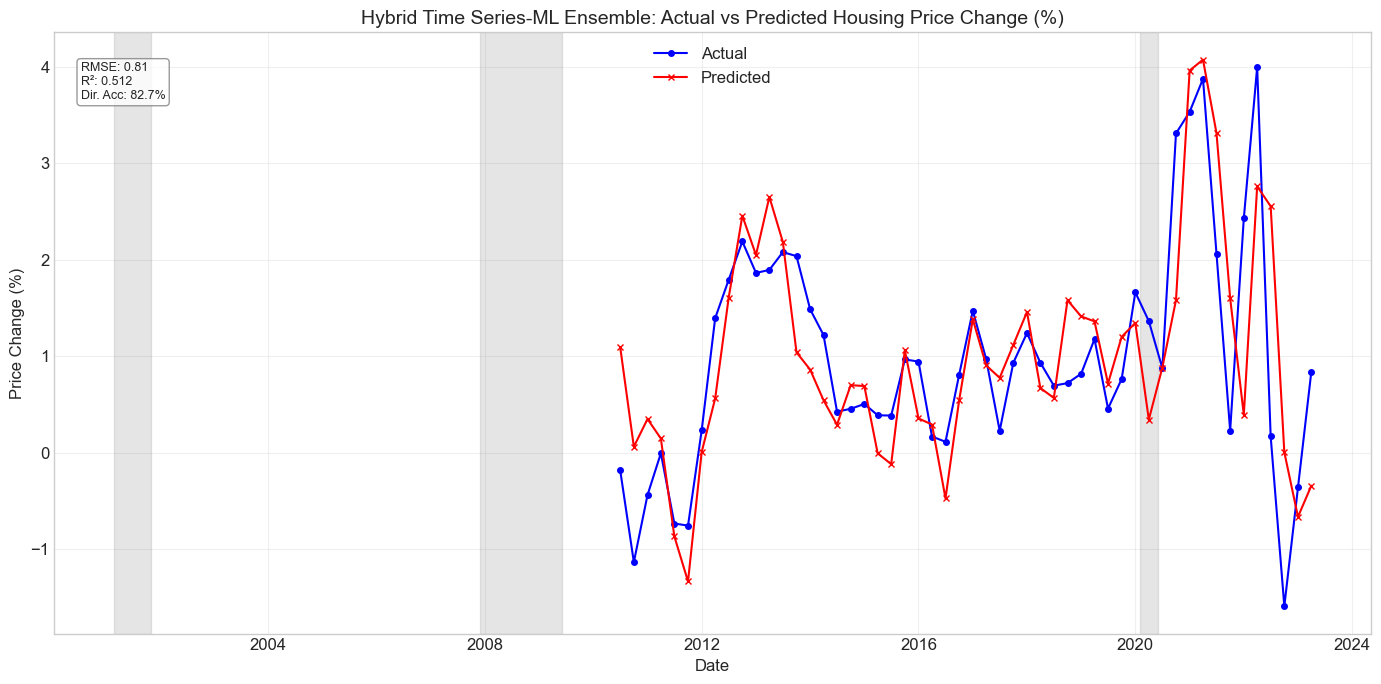

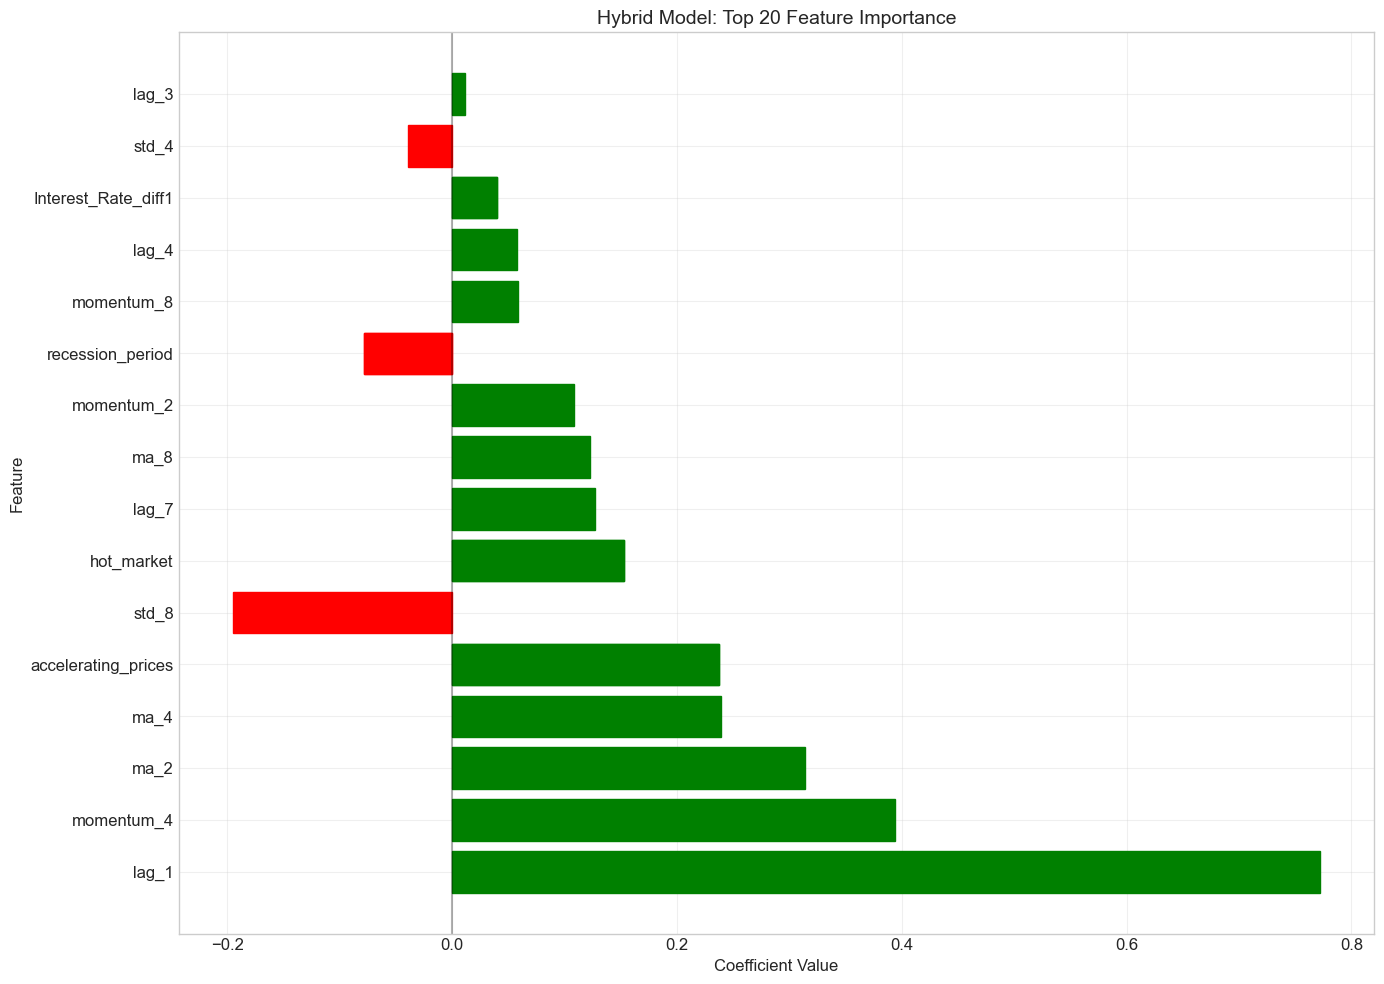


===== EVALUATING MODELS BY MARKET REGIME =====


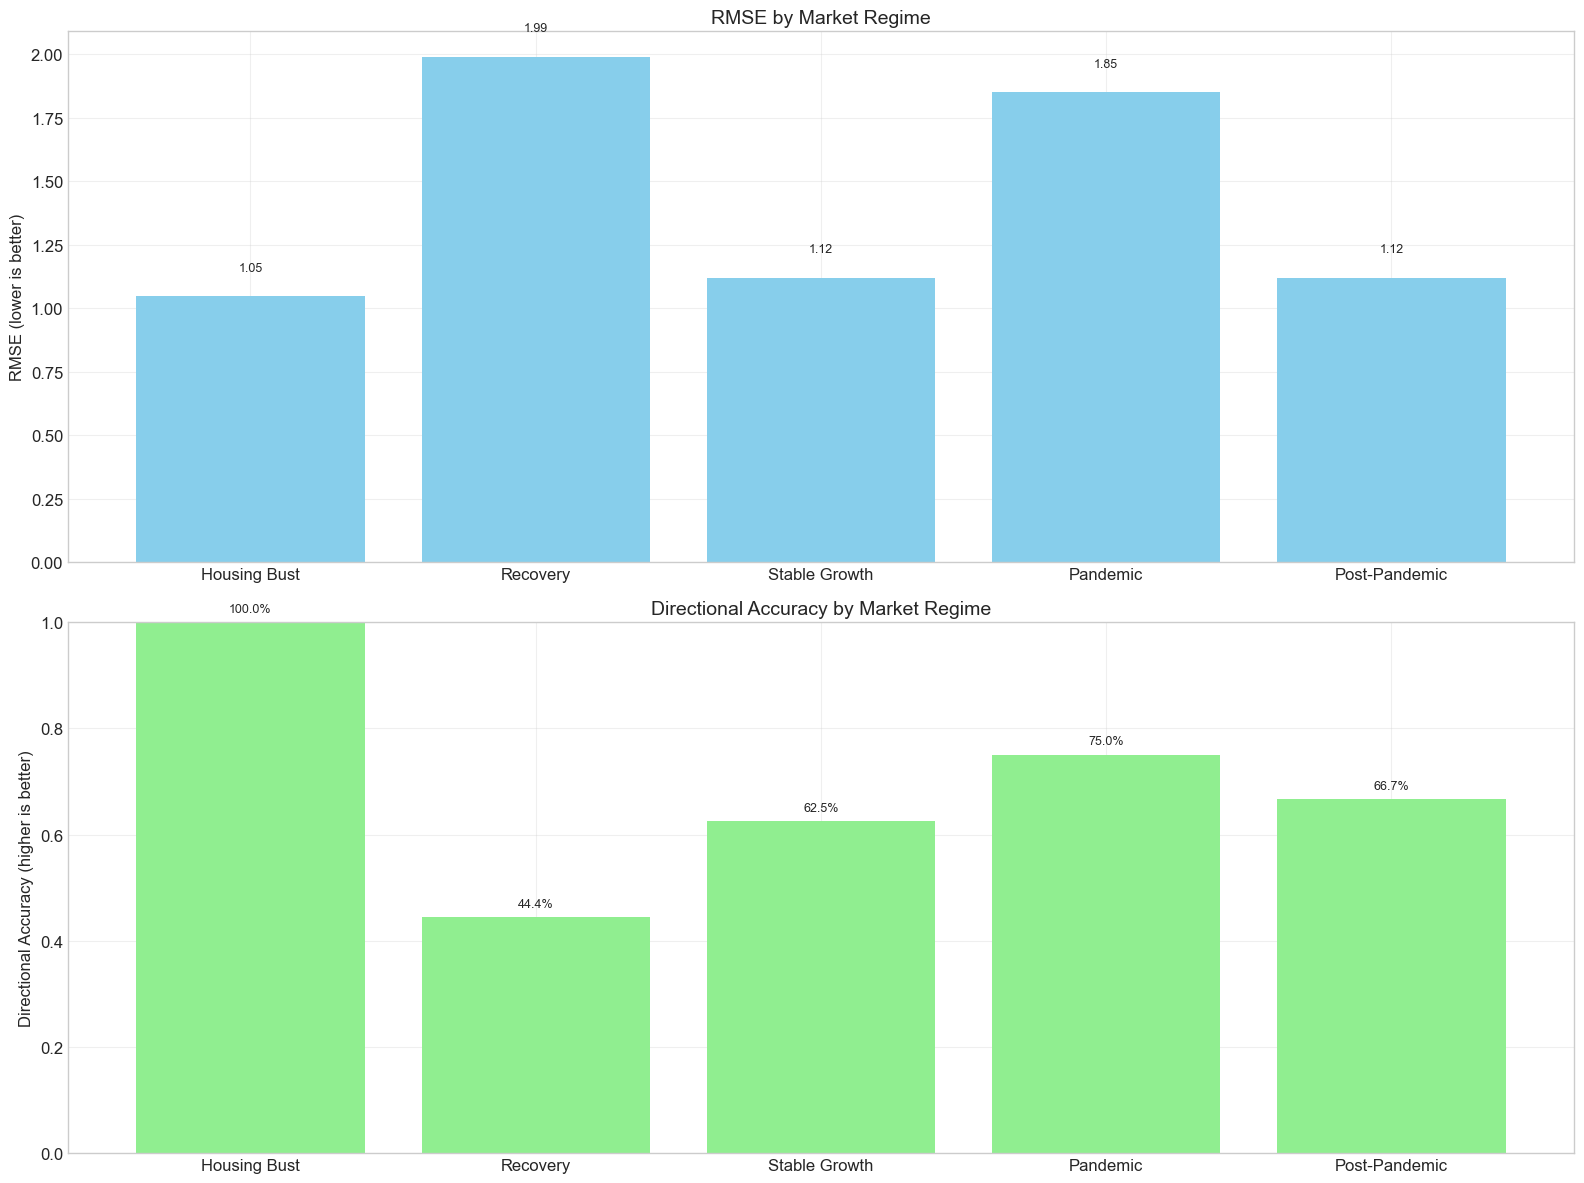

Performance by market regime:
                   rmse        r2   dir_acc  n_samples
Housing Bust   1.047888 -6.056937  1.000000          2
Recovery       1.991438 -1.570287  0.444444         18
Stable Growth  1.120694 -7.520338  0.625000         24
Pandemic       1.851589 -1.210120  0.750000          8
Post-Pandemic  1.120106  0.628575  0.666667          6

===== CALCULATING CUSTOM METRICS =====
Custom metrics:
mape: 445.3280802852349
dir_acc: 0.603448275862069
extreme_up_acc: 0.8333333333333334
extreme_down_acc: 1.0
tracking_error: 1.2691177016208899
turning_point_acc: 0.4
n_turning_points: 5

===== COMPARING ALL MODELS =====


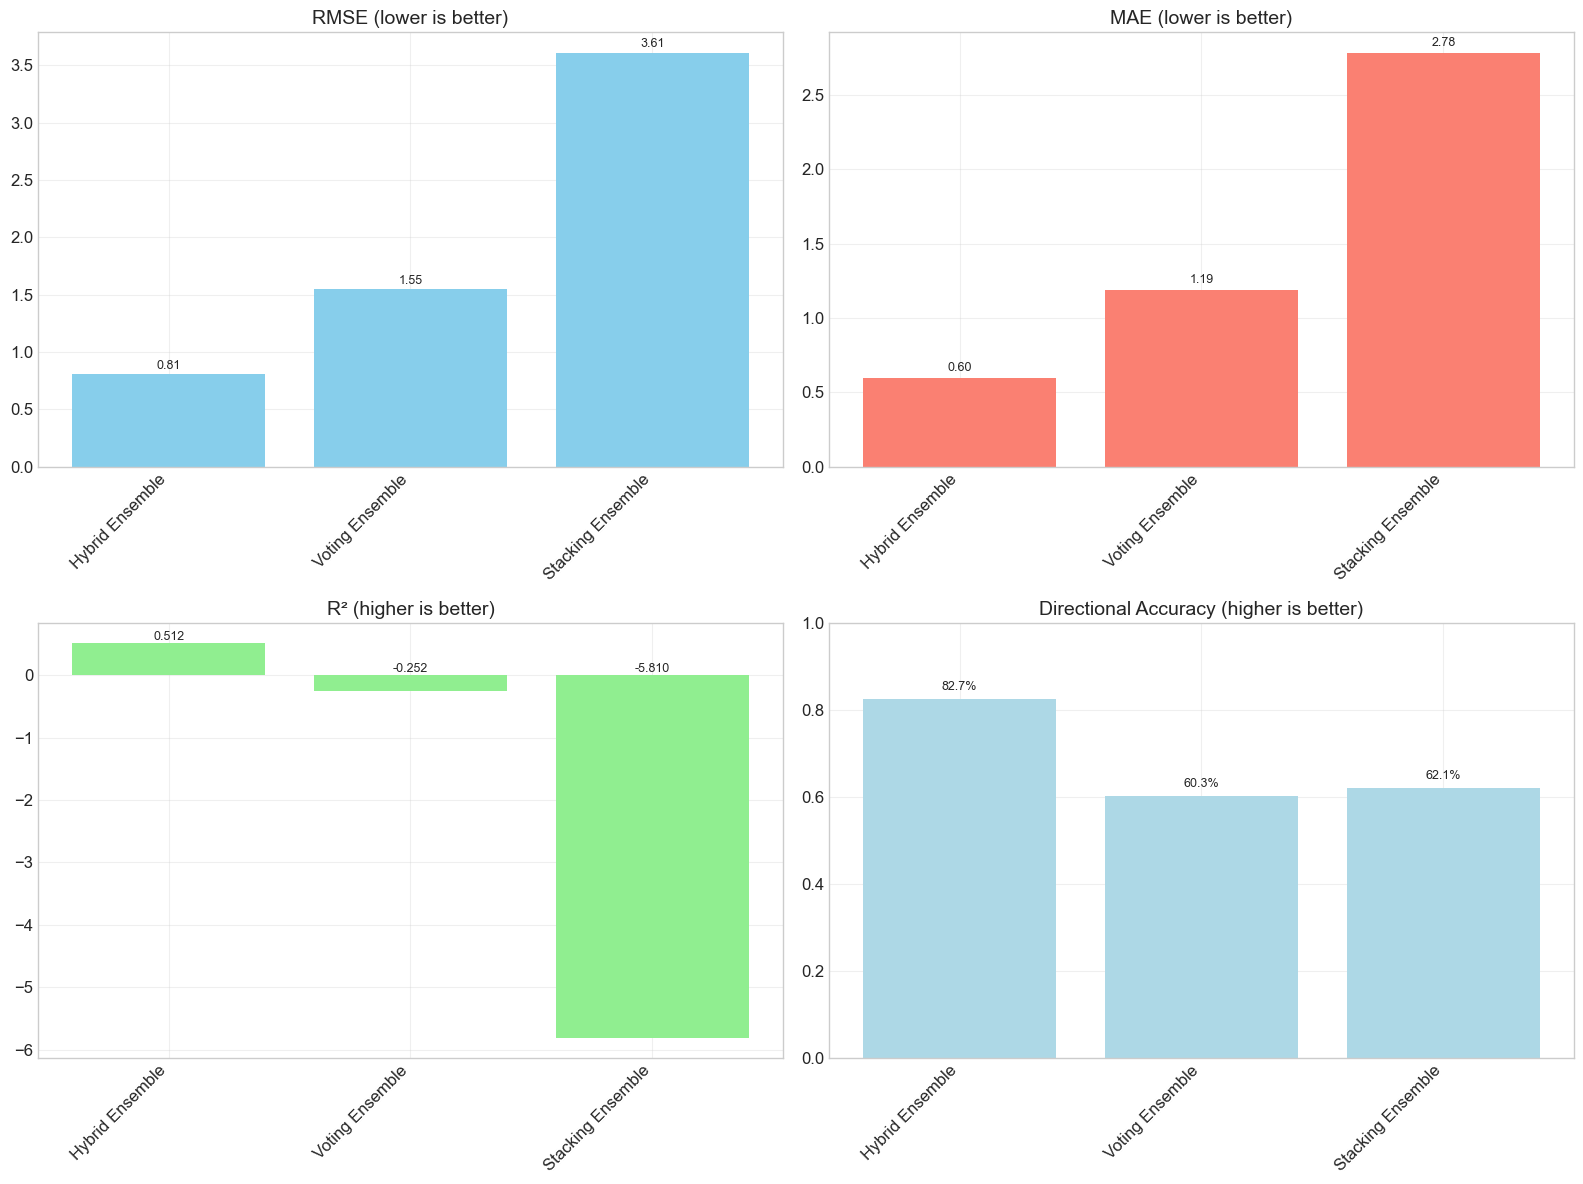

Model Comparison:
                       rmse       mae        r2   dir_acc
Hybrid Ensemble    0.805739  0.596332  0.512470  0.826923
Voting Ensemble    1.546290  1.186538 -0.252079  0.603448
Stacking Ensemble  3.606291  2.782959 -5.810373  0.620690

Best model by metric:
Best RMSE: Hybrid Ensemble (0.81)
Best MAE: Hybrid Ensemble (0.60)
Best R²: Hybrid Ensemble (0.512)
Best Directional Accuracy: Hybrid Ensemble (82.7%)

===== CREATING FORECAST =====


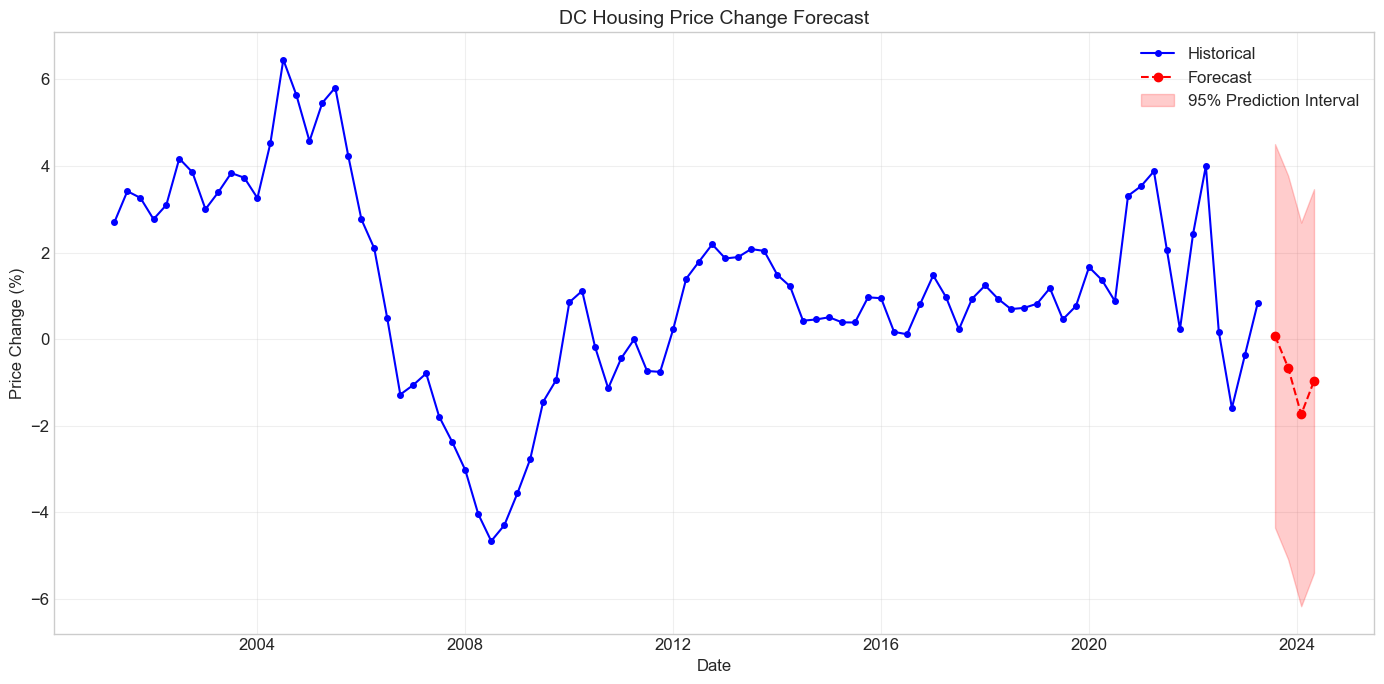

Housing Price Change Forecast:
            Forecast_ZHVI_pct_change  ZHVI_forecast
2023-07-31                  0.074624  500373.120498
2023-10-31                 -0.654469  497098.332619
2024-01-31                 -1.737740  488460.058509
2024-04-30                 -0.965392  483744.502313


In [1]:
# DC Housing Market Ensemble Models and Comprehensive Evaluation
# This script implements ensemble approaches and provides comprehensive model evaluation

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, VotingRegressor, StackingRegressor
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

# Set visualization styling
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 12

# -------------------------------------------------------------
# 1. Data Loading for Ensemble Modeling
# -------------------------------------------------------------

def load_all_datasets():
    """Load all prepared datasets for ensemble modeling"""
    # Original datasets
    df_clean = pd.read_csv('dc_housing_modeling_features_clean.csv', parse_dates=['Date'], index_col='Date')
    df_partial = pd.read_csv('dc_housing_modeling_features_partial.csv', parse_dates=['Date'], index_col='Date')
    
    # Additional feature-engineered datasets if they exist
    try:
        df_enhanced = pd.read_csv('dc_housing_enhanced_features.csv', parse_dates=['Date'], index_col='Date')
        print(f"Enhanced features dataset loaded: {df_enhanced.shape}")
    except:
        df_enhanced = None
        print("Enhanced features dataset not found.")
    
    try:
        df_hybrid = pd.read_csv('dc_housing_time_series_features.csv', parse_dates=['Date'], index_col='Date')
        print(f"Hybrid time series features dataset loaded: {df_hybrid.shape}")
    except:
        df_hybrid = None
        print("Hybrid time series features dataset not found.")
    
    return {
        'clean': df_clean,
        'partial': df_partial,
        'enhanced': df_enhanced,
        'hybrid': df_hybrid
    }

# -------------------------------------------------------------
# 2. Ensemble Models Implementation
# -------------------------------------------------------------

def implement_voting_ensemble(X, y, cv):
    """Implement a voting ensemble of multiple regression models"""
    # Standardize features
    scaler = StandardScaler()
    X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)
    
    # Define base models
    ridge = Ridge(alpha=70)  # From previous optimal hyperparameter
    lasso = Lasso(alpha=0.1, max_iter=10000)
    elastic = ElasticNet(alpha=0.5, l1_ratio=0.7, max_iter=10000)
    gbm = GradientBoostingRegressor(
        n_estimators=200, 
        learning_rate=0.05, 
        max_depth=3, 
        subsample=0.8,
        random_state=42
    )
    
    # Define voting ensemble
    voting_regressor = VotingRegressor(
        estimators=[
            ('ridge', ridge),
            ('lasso', lasso),
            ('elastic', elastic),
            ('gbm', gbm)
        ]
    )
    
    # For storing predictions
    all_y_test = []
    all_y_pred = []
    all_test_indices = []
    
    for train_idx, test_idx in cv.split(X_scaled):
        X_train, X_test = X_scaled.iloc[train_idx], X_scaled.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        # Train the model
        voting_regressor.fit(X_train, y_train)
        
        # Make predictions
        y_pred = voting_regressor.predict(X_test)
        
        # Store results
        all_y_test.extend(y_test)
        all_y_pred.extend(y_pred)
        all_test_indices.extend(test_idx)
    
    # Calculate performance metrics
    rmse = np.sqrt(mean_squared_error(all_y_test, all_y_pred))
    mae = mean_absolute_error(all_y_test, all_y_pred)
    r2 = r2_score(all_y_test, all_y_pred)
    
    # Calculate directional accuracy
    actual_direction = np.sign(all_y_test)
    pred_direction = np.sign(all_y_pred)
    dir_acc = np.mean(actual_direction == pred_direction)
    
    print("Voting Ensemble Performance:")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"R²: {r2:.4f}")
    print(f"Directional Accuracy: {dir_acc:.2%}")
    
    # Create a results dataframe
    results_df = pd.DataFrame({
        'Index': X.iloc[all_test_indices].index,
        'Actual': all_y_test,
        'Predicted': all_y_pred
    }).sort_values('Index')
    
    # Plot results
    plt.figure(figsize=(14, 7))
    plt.plot(results_df['Index'], results_df['Actual'], 'o-', markersize=4, label='Actual', color='blue')
    plt.plot(results_df['Index'], results_df['Predicted'], 'x-', markersize=4, label='Predicted', color='red')
    plt.title('Voting Ensemble: Actual vs Predicted Housing Price Change (%)', fontsize=14)
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Price Change (%)', fontsize=12)
    
    # Add recession shading
    recession_periods = [
        ('2001-03-01', '2001-11-01'),  # Dot-com bubble
        ('2007-12-01', '2009-06-01'),  # Great Recession
        ('2020-02-01', '2020-06-01')   # COVID-19 Recession
    ]
    
    for start, end in recession_periods:
        plt.axvspan(pd.to_datetime(start), pd.to_datetime(end), alpha=0.2, color='gray')
    
    # Add metrics as text
    metrics_text = (f"RMSE: {rmse:.2f}\n"
                   f"R²: {r2:.3f}\n"
                   f"Dir. Acc: {dir_acc:.1%}")
    
    plt.annotate(metrics_text, xy=(0.02, 0.95), xycoords='axes fraction',
                 bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8),
                 fontsize=9, ha='left', va='top')
    
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('outputs/voting_ensemble_predictions.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    metrics = {
        'rmse': rmse,
        'mae': mae,
        'r2': r2,
        'dir_acc': dir_acc
    }
    
    return results_df, metrics, voting_regressor

def implement_stacking_ensemble(X, y, cv):
    """Implement a stacking ensemble of multiple regression models"""
    # Standardize features
    scaler = StandardScaler()
    X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)
    
    # Define base models
    estimators = [
        ('ridge', Ridge(alpha=70)),
        ('lasso', Lasso(alpha=0.1, max_iter=10000)),
        ('elastic', ElasticNet(alpha=0.5, l1_ratio=0.7, max_iter=10000)),
        ('rf', RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)),
        ('gbm', GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=3, random_state=42)),
        ('xgb', xgb.XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=3, random_state=42))
    ]
    
    # Define stacking ensemble with ElasticNet as the final estimator
    stacking_regressor = StackingRegressor(
        estimators=estimators,
        final_estimator=ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000)
    )
    
    # For storing predictions
    all_y_test = []
    all_y_pred = []
    all_test_indices = []
    
    for train_idx, test_idx in cv.split(X_scaled):
        X_train, X_test = X_scaled.iloc[train_idx], X_scaled.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        # Train the model
        stacking_regressor.fit(X_train, y_train)
        
        # Make predictions
        y_pred = stacking_regressor.predict(X_test)
        
        # Store results
        all_y_test.extend(y_test)
        all_y_pred.extend(y_pred)
        all_test_indices.extend(test_idx)
    
    # Calculate performance metrics
    rmse = np.sqrt(mean_squared_error(all_y_test, all_y_pred))
    mae = mean_absolute_error(all_y_test, all_y_pred)
    r2 = r2_score(all_y_test, all_y_pred)
    
    # Calculate directional accuracy
    actual_direction = np.sign(all_y_test)
    pred_direction = np.sign(all_y_pred)
    dir_acc = np.mean(actual_direction == pred_direction)
    
    print("Stacking Ensemble Performance:")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"R²: {r2:.4f}")
    print(f"Directional Accuracy: {dir_acc:.2%}")
    
    # Create a results dataframe
    results_df = pd.DataFrame({
        'Index': X.iloc[all_test_indices].index,
        'Actual': all_y_test,
        'Predicted': all_y_pred
    }).sort_values('Index')
    
    # Plot results
    plt.figure(figsize=(14, 7))
    plt.plot(results_df['Index'], results_df['Actual'], 'o-', markersize=4, label='Actual', color='blue')
    plt.plot(results_df['Index'], results_df['Predicted'], 'x-', markersize=4, label='Predicted', color='red')
    plt.title('Stacking Ensemble: Actual vs Predicted Housing Price Change (%)', fontsize=14)
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Price Change (%)', fontsize=12)
    
    # Add recession shading
    recession_periods = [
        ('2001-03-01', '2001-11-01'),  # Dot-com bubble
        ('2007-12-01', '2009-06-01'),  # Great Recession
        ('2020-02-01', '2020-06-01')   # COVID-19 Recession
    ]
    
    for start, end in recession_periods:
        plt.axvspan(pd.to_datetime(start), pd.to_datetime(end), alpha=0.2, color='gray')
    
    # Add metrics as text
    metrics_text = (f"RMSE: {rmse:.2f}\n"
                   f"R²: {r2:.3f}\n"
                   f"Dir. Acc: {dir_acc:.1%}")
    
    plt.annotate(metrics_text, xy=(0.02, 0.95), xycoords='axes fraction',
                 bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8),
                 fontsize=9, ha='left', va='top')
    
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('outputs/stacking_ensemble_predictions.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    metrics = {
        'rmse': rmse,
        'mae': mae,
        'r2': r2,
        'dir_acc': dir_acc
    }
    
    return results_df, metrics, stacking_regressor

def implement_time_series_ml_ensemble(X_ml, X_ts, y, cv):
    """Implement ensemble that combines ML features with time series features"""
    # If hybrid time series features dataset is not available, create it
    if X_ts is None:
        print("Time series features not available. Skipping hybrid ensemble.")
        return None, None, None
    
    # Ensure both datasets have the same index
    common_index = X_ml.index.intersection(X_ts.index)
    X_ml = X_ml.loc[common_index]
    X_ts = X_ts.loc[common_index]
    y = y.loc[common_index]
    
    # Combine features
    X_combined = pd.concat([X_ml, X_ts.drop('ZHVI_pct_change', axis=1, errors='ignore')], axis=1)
    print(f"Combined feature set shape: {X_combined.shape}")
    
    # Standardize features
    scaler = StandardScaler()
    X_scaled = pd.DataFrame(scaler.fit_transform(X_combined), columns=X_combined.columns, index=X_combined.index)
    
    # Use ElasticNet as the base model since it performed well in previous experiments
    hybrid_model = ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000)
    
    # For storing predictions
    all_y_test = []
    all_y_pred = []
    all_test_indices = []
    
    for train_idx, test_idx in cv.split(X_scaled):
        X_train, X_test = X_scaled.iloc[train_idx], X_scaled.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        # Train the model
        hybrid_model.fit(X_train, y_train)
        
        # Make predictions
        y_pred = hybrid_model.predict(X_test)
        
        # Store results
        all_y_test.extend(y_test)
        all_y_pred.extend(y_pred)
        all_test_indices.extend(test_idx)
    
    # Calculate performance metrics
    rmse = np.sqrt(mean_squared_error(all_y_test, all_y_pred))
    mae = mean_absolute_error(all_y_test, all_y_pred)
    r2 = r2_score(all_y_test, all_y_pred)
    
    # Calculate directional accuracy
    actual_direction = np.sign(all_y_test)
    pred_direction = np.sign(all_y_pred)
    dir_acc = np.mean(actual_direction == pred_direction)
    
    print("Hybrid Time Series-ML Ensemble Performance:")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"R²: {r2:.4f}")
    print(f"Directional Accuracy: {dir_acc:.2%}")
    
    # Create a results dataframe
    results_df = pd.DataFrame({
        'Index': X_combined.iloc[all_test_indices].index,
        'Actual': all_y_test,
        'Predicted': all_y_pred
    }).sort_values('Index')
    
    # Plot results
    plt.figure(figsize=(14, 7))
    plt.plot(results_df['Index'], results_df['Actual'], 'o-', markersize=4, label='Actual', color='blue')
    plt.plot(results_df['Index'], results_df['Predicted'], 'x-', markersize=4, label='Predicted', color='red')
    plt.title('Hybrid Time Series-ML Ensemble: Actual vs Predicted Housing Price Change (%)', fontsize=14)
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Price Change (%)', fontsize=12)
    
    # Add recession shading
    recession_periods = [
        ('2001-03-01', '2001-11-01'),  # Dot-com bubble
        ('2007-12-01', '2009-06-01'),  # Great Recession
        ('2020-02-01', '2020-06-01')   # COVID-19 Recession
    ]
    
    for start, end in recession_periods:
        plt.axvspan(pd.to_datetime(start), pd.to_datetime(end), alpha=0.2, color='gray')
    
    # Add metrics as text
    metrics_text = (f"RMSE: {rmse:.2f}\n"
                   f"R²: {r2:.3f}\n"
                   f"Dir. Acc: {dir_acc:.1%}")
    
    plt.annotate(metrics_text, xy=(0.02, 0.95), xycoords='axes fraction',
                 bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.8),
                 fontsize=9, ha='left', va='top')
    
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('outputs/hybrid_ensemble_predictions.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Get feature importance
    feature_importance = pd.DataFrame({
        'Feature': X_combined.columns,
        'Coefficient': hybrid_model.coef_,
        'Abs_Coefficient': np.abs(hybrid_model.coef_)
    }).sort_values('Abs_Coefficient', ascending=False)
    
    # Plot top feature importance
    plt.figure(figsize=(14, 10))
    top_features = feature_importance.head(20)
    bars = plt.barh(top_features['Feature'], top_features['Coefficient'])
    
    # Color the bars based on the sign of the coefficient
    for i, bar in enumerate(bars):
        if top_features.iloc[i]['Coefficient'] < 0:
            bar.set_color('red')
        else:
            bar.set_color('green')
    
    plt.title('Hybrid Model: Top 20 Feature Importance', fontsize=14)
    plt.xlabel('Coefficient Value', fontsize=12)
    plt.ylabel('Feature', fontsize=12)
    plt.axvline(x=0, color='black', linestyle='-', alpha=0.3)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('outputs/hybrid_feature_importance.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    metrics = {
        'rmse': rmse,
        'mae': mae,
        'r2': r2,
        'dir_acc': dir_acc
    }
    
    return results_df, metrics, hybrid_model

# -------------------------------------------------------------
# 3. Advanced Model Evaluation
# -------------------------------------------------------------

def evaluate_model_by_market_regime(results_df, regimes):
    """Evaluate model performance across different market regimes"""
    # Define market regimes with specific date ranges
    regime_periods = {
        'Housing Boom': (pd.to_datetime('2002-01-01'), pd.to_datetime('2006-04-30')),
        'Housing Bust': (pd.to_datetime('2006-05-01'), pd.to_datetime('2009-05-31')),
        'Recovery': (pd.to_datetime('2009-06-01'), pd.to_datetime('2013-12-31')),
        'Stable Growth': (pd.to_datetime('2014-01-01'), pd.to_datetime('2019-12-31')),
        'Pandemic': (pd.to_datetime('2020-01-01'), pd.to_datetime('2021-12-31')),
        'Post-Pandemic': (pd.to_datetime('2022-01-01'), pd.to_datetime('2024-12-31'))
    }
    
    # Initialize metrics by regime
    regime_metrics = {}
    
    # Calculate metrics for each regime
    for regime, (start_date, end_date) in regime_periods.items():
        regime_data = results_df[(results_df['Index'] >= start_date) & (results_df['Index'] <= end_date)]
        
        if len(regime_data) > 0:
            rmse = np.sqrt(mean_squared_error(regime_data['Actual'], regime_data['Predicted']))
            r2 = r2_score(regime_data['Actual'], regime_data['Predicted'])
            
            # Calculate directional accuracy
            actual_direction = np.sign(regime_data['Actual'])
            pred_direction = np.sign(regime_data['Predicted'])
            dir_acc = np.mean(actual_direction == pred_direction)
            
            regime_metrics[regime] = {
                'rmse': rmse,
                'r2': r2,
                'dir_acc': dir_acc,
                'n_samples': len(regime_data)
            }
    
    # Convert to DataFrame for display
    metrics_df = pd.DataFrame.from_dict(regime_metrics, orient='index')
    
    # Plot performance by regime
    plt.figure(figsize=(16, 12))
    
    # Plot RMSE by regime
    plt.subplot(2, 1, 1)
    bars = plt.bar(metrics_df.index, metrics_df['rmse'], color='skyblue')
    plt.title('RMSE by Market Regime', fontsize=14)
    plt.ylabel('RMSE (lower is better)', fontsize=12)
    plt.grid(True, alpha=0.3)
    
    # Add value labels
    for i, bar in enumerate(bars):
        plt.text(i, bar.get_height() + 0.1, f"{metrics_df['rmse'].iloc[i]:.2f}", 
                 ha='center', fontsize=9)
    
    # Plot Directional Accuracy by regime
    plt.subplot(2, 1, 2)
    bars = plt.bar(metrics_df.index, metrics_df['dir_acc'], color='lightgreen')
    plt.title('Directional Accuracy by Market Regime', fontsize=14)
    plt.ylabel('Directional Accuracy (higher is better)', fontsize=12)
    plt.ylim(0, 1)
    plt.grid(True, alpha=0.3)
    
    # Add value labels
    for i, bar in enumerate(bars):
        plt.text(i, bar.get_height() + 0.02, f"{metrics_df['dir_acc'].iloc[i]:.1%}", 
                 ha='center', fontsize=9)
    
    plt.tight_layout()
    plt.savefig('outputs/performance_by_regime.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("Performance by market regime:")
    print(metrics_df.to_string())
    
    return metrics_df

def calculate_custom_metrics(results_df):
    """Calculate additional custom metrics relevant to housing market prediction"""
    # 1. Mean absolute percentage error (MAPE)
    # Filter out cases where actual is zero to avoid division by zero
    non_zero_actual = results_df[results_df['Actual'] != 0]
    mape = np.mean(np.abs((non_zero_actual['Actual'] - non_zero_actual['Predicted']) / non_zero_actual['Actual'])) * 100
    
    # 2. Directional accuracy (already calculated in the main evaluation)
    actual_direction = np.sign(results_df['Actual'])
    pred_direction = np.sign(results_df['Predicted'])
    dir_acc = np.mean(actual_direction == pred_direction)
    
    # 3. Extreme event accuracy (for price changes > 1.5 standard deviations)
    std_dev = results_df['Actual'].std()
    threshold = 1.5 * std_dev
    
    extreme_up = results_df[results_df['Actual'] > threshold]
    extreme_down = results_df[results_df['Actual'] < -threshold]
    
    if len(extreme_up) > 0:
        extreme_up_acc = np.mean(extreme_up['Predicted'] > 0)
    else:
        extreme_up_acc = np.nan
    
    if len(extreme_down) > 0:
        extreme_down_acc = np.mean(extreme_down['Predicted'] < 0)
    else:
        extreme_down_acc = np.nan
    
    # 4. Tracking error (standard deviation of prediction errors)
    tracking_error = np.std(results_df['Actual'] - results_df['Predicted'])
    
    # 5. Turning point detection (when price movement changes direction)
    turning_points = []
    actual_direction_change = []
    pred_direction_change = []
    
    for i in range(1, len(results_df)):
        if np.sign(results_df['Actual'].iloc[i]) != np.sign(results_df['Actual'].iloc[i-1]):
            turning_points.append(i)
            actual_direction_change.append(np.sign(results_df['Actual'].iloc[i]))
            pred_direction_change.append(np.sign(results_df['Predicted'].iloc[i]))
    
    if turning_points:
        turning_point_acc = np.mean(np.array(actual_direction_change) == np.array(pred_direction_change))
    else:
        turning_point_acc = np.nan
    
    # Compile custom metrics
    custom_metrics = {
        'mape': mape,
        'dir_acc': dir_acc,
        'extreme_up_acc': extreme_up_acc,
        'extreme_down_acc': extreme_down_acc,
        'tracking_error': tracking_error,
        'turning_point_acc': turning_point_acc,
        'n_turning_points': len(turning_points)
    }
    
    print("Custom metrics:")
    for metric, value in custom_metrics.items():
        print(f"{metric}: {value}")
    
    return custom_metrics

def compare_all_models(all_results):
    """Compare all models and create a comprehensive comparison table"""
    comparison = {}
    
    for model_name, results in all_results.items():
        if results is not None and results[1] is not None:  # Check if metrics exist
            comparison[model_name] = results[1]
    
    # Convert to DataFrame for display
    comparison_df = pd.DataFrame.from_dict(comparison, orient='index')
    
    # Sort by RMSE (lower is better)
    comparison_df = comparison_df.sort_values('rmse')
    
    # Plot comparison
    plt.figure(figsize=(16, 12))
    
    # Plot RMSE
    plt.subplot(2, 2, 1)
    bars = plt.bar(comparison_df.index, comparison_df['rmse'], color='skyblue')
    plt.title('RMSE (lower is better)', fontsize=14)
    plt.xticks(rotation=45, ha='right')
    plt.grid(True, alpha=0.3)
    
    # Add value labels
    for i, bar in enumerate(bars):
        plt.text(i, bar.get_height() + 0.05, f"{comparison_df['rmse'].iloc[i]:.2f}", 
                 ha='center', fontsize=9)
    
    # Plot MAE
    plt.subplot(2, 2, 2)
    bars = plt.bar(comparison_df.index, comparison_df['mae'], color='salmon')
    plt.title('MAE (lower is better)', fontsize=14)
    plt.xticks(rotation=45, ha='right')
    plt.grid(True, alpha=0.3)
    
    # Add value labels
    for i, bar in enumerate(bars):
        plt.text(i, bar.get_height() + 0.05, f"{comparison_df['mae'].iloc[i]:.2f}", 
                 ha='center', fontsize=9)
    
    # Plot R²
    plt.subplot(2, 2, 3)
    bars = plt.bar(comparison_df.index, comparison_df['r2'], color='lightgreen')
    plt.title('R² (higher is better)', fontsize=14)
    plt.xticks(rotation=45, ha='right')
    plt.grid(True, alpha=0.3)
    
    # Add value labels
    for i, bar in enumerate(bars):
        # For negative values, place text above the bar
        if comparison_df['r2'].iloc[i] < 0:
            plt.text(i, 0.05, f"{comparison_df['r2'].iloc[i]:.3f}", 
                    ha='center', fontsize=9)
        else:
            plt.text(i, bar.get_height() + 0.05, f"{comparison_df['r2'].iloc[i]:.3f}", 
                    ha='center', fontsize=9)
    
    # Plot Directional Accuracy
    plt.subplot(2, 2, 4)
    bars = plt.bar(comparison_df.index, comparison_df['dir_acc'], color='lightblue')
    plt.title('Directional Accuracy (higher is better)', fontsize=14)
    plt.ylim(0, 1)
    plt.xticks(rotation=45, ha='right')
    plt.grid(True, alpha=0.3)
    
    # Add value labels
    for i, bar in enumerate(bars):
        plt.text(i, bar.get_height() + 0.02, f"{comparison_df['dir_acc'].iloc[i]:.1%}", 
                 ha='center', fontsize=9)
    
    plt.tight_layout()
    plt.savefig('outputs/model_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("Model Comparison:")
    print(comparison_df.to_string())
    
    # Identify best model for each metric
    best_rmse = comparison_df['rmse'].idxmin()
    best_mae = comparison_df['mae'].idxmin()
    best_r2 = comparison_df['r2'].idxmax()
    best_dir_acc = comparison_df['dir_acc'].idxmax()
    
    print("\nBest model by metric:")
    print(f"Best RMSE: {best_rmse} ({comparison_df.loc[best_rmse, 'rmse']:.2f})")
    print(f"Best MAE: {best_mae} ({comparison_df.loc[best_mae, 'mae']:.2f})")
    print(f"Best R²: {best_r2} ({comparison_df.loc[best_r2, 'r2']:.3f})")
    print(f"Best Directional Accuracy: {best_dir_acc} ({comparison_df.loc[best_dir_acc, 'dir_acc']:.1%})")
    
    return comparison_df

# -------------------------------------------------------------
# 4. Future Forecasting
# -------------------------------------------------------------

def create_forecast(best_model, X, y, n_quarters=4):
    """Create a forecast for future quarters using the best model"""
    # Fit the model on all available data
    X_scaled = StandardScaler().fit_transform(X)
    best_model.fit(X_scaled, y)
    
    # Create future date range
    last_date = y.index[-1]
    forecast_dates = pd.date_range(start=pd.Timestamp(last_date) + pd.DateOffset(months=3), 
                                  periods=n_quarters, freq='3M')
    
    # Assuming we'll use the last available feature values for forecasting
    # In reality, you'd need to predict these features or use expert judgment
    last_features = X.iloc[-1].values.reshape(1, -1)
    last_features_scaled = StandardScaler().fit(X).transform(last_features)
    
    # For demonstration, we'll create slight variations for future quarters
    future_features = []
    for i in range(n_quarters):
        # Add small random variations to the last known features
        # This is a simplified approach - in practice, you'd need to model these features
        variation = np.random.normal(0, 0.1, size=last_features.shape)
        future_quarter = last_features + variation * (i + 1)
        future_features.append(future_quarter[0])
    
    future_features_df = pd.DataFrame(future_features, columns=X.columns, index=forecast_dates)
    future_features_scaled = StandardScaler().fit(X).transform(future_features_df)
    
    # Generate predictions
    forecast = best_model.predict(future_features_scaled)
    
    # Create forecast dataframe
    forecast_df = pd.DataFrame({
        'Forecast_ZHVI_pct_change': forecast
    }, index=forecast_dates)
    
    # Calculate potential price levels based on the last known price
    # For simplicity, we'll assume the last ZHVI value was 500,000
    last_zhvi = 500000  # Placeholder, replace with actual last ZHVI
    forecast_df['ZHVI_forecast'] = last_zhvi
    
    for i, row in forecast_df.iterrows():
        if i == forecast_df.index[0]:
            forecast_df.at[i, 'ZHVI_forecast'] = last_zhvi * (1 + row['Forecast_ZHVI_pct_change']/100)
        else:
            prev_zhvi = forecast_df.at[forecast_df.index[forecast_df.index.get_loc(i)-1], 'ZHVI_forecast']
            forecast_df.at[i, 'ZHVI_forecast'] = prev_zhvi * (1 + row['Forecast_ZHVI_pct_change']/100)
    
    # Plot forecast
    plt.figure(figsize=(14, 7))
    
    # Plot historical data
    plt.plot(y.index, y, 'o-', markersize=4, label='Historical', color='blue')
    
    # Plot forecast with prediction interval
    plt.plot(forecast_df.index, forecast_df['Forecast_ZHVI_pct_change'], 'o--', markersize=6, 
             label='Forecast', color='red')
    
    # Add shaded area for prediction interval (assumed)
    std_dev = y.std()
    upper_bound = forecast_df['Forecast_ZHVI_pct_change'] + 1.96 * std_dev
    lower_bound = forecast_df['Forecast_ZHVI_pct_change'] - 1.96 * std_dev
    
    plt.fill_between(forecast_df.index, lower_bound, upper_bound, alpha=0.2, color='red',
                    label='95% Prediction Interval')
    
    plt.title('DC Housing Price Change Forecast', fontsize=14)
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Price Change (%)', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig('outputs/price_forecast.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("Housing Price Change Forecast:")
    print(forecast_df.to_string())
    
    return forecast_df

# -------------------------------------------------------------
# 5. Main Execution
# -------------------------------------------------------------

def main():
    """Main execution function"""
    print("==== DC HOUSING MARKET ENSEMBLE MODELS AND EVALUATION ====")
    
    # 1. Load all datasets
    datasets = load_all_datasets()
    
    # 2. Set up time series cross-validation
    tscv = TimeSeriesSplit(n_splits=2)  # Use 2-fold CV as found optimal
    
    # 3. Define target variable and features for each dataset
    results = {}
    
    # Clean dataset (for linear models)
    X_clean = datasets['clean'].drop('ZHVI_pct_change', axis=1)
    y_clean = datasets['clean']['ZHVI_pct_change']
    
    # Partial dataset (for tree-based models)
    X_partial = datasets['partial'].drop('ZHVI_pct_change', axis=1)
    y_partial = datasets['partial']['ZHVI_pct_change']
    
    # Enhanced features dataset (if available)
    if datasets['enhanced'] is not None:
        X_enhanced = datasets['enhanced'].drop('ZHVI_pct_change', axis=1)
        y_enhanced = datasets['enhanced']['ZHVI_pct_change']
    else:
        X_enhanced = None
        y_enhanced = None
    
    # Hybrid time series features dataset (if available)
    if datasets['hybrid'] is not None:
        X_hybrid = datasets['hybrid'].drop('ZHVI_pct_change', axis=1, errors='ignore')
        y_hybrid = datasets['hybrid']['ZHVI_pct_change']
    else:
        X_hybrid = None
        y_hybrid = None
    
    # 4. Implement ensemble models
    print("\n===== IMPLEMENTING VOTING ENSEMBLE =====")
    voting_results, voting_metrics, voting_model = implement_voting_ensemble(X_clean, y_clean, tscv)
    results['Voting Ensemble'] = (voting_results, voting_metrics, voting_model)
    
    print("\n===== IMPLEMENTING STACKING ENSEMBLE =====")
    stacking_results, stacking_metrics, stacking_model = implement_stacking_ensemble(X_clean, y_clean, tscv)
    results['Stacking Ensemble'] = (stacking_results, stacking_metrics, stacking_model)
    
    print("\n===== IMPLEMENTING HYBRID TIME SERIES-ML ENSEMBLE =====")
    if X_hybrid is not None:
        hybrid_results, hybrid_metrics, hybrid_model = implement_time_series_ml_ensemble(
            X_clean, X_hybrid, y_clean, tscv
        )
        results['Hybrid Ensemble'] = (hybrid_results, hybrid_metrics, hybrid_model)
    
    # 5. Advanced model evaluation
    if voting_results is not None:
        print("\n===== EVALUATING MODELS BY MARKET REGIME =====")
        regime_metrics = evaluate_model_by_market_regime(voting_results, None)
        
        print("\n===== CALCULATING CUSTOM METRICS =====")
        custom_metrics = calculate_custom_metrics(voting_results)
    
    # 6. Compare all models
    print("\n===== COMPARING ALL MODELS =====")
    comparison_df = compare_all_models(results)
    
    # 7. Create forecast with best model
    print("\n===== CREATING FORECAST =====")
    best_model_name = comparison_df.index[0]  # Best model by RMSE
    best_model = results[best_model_name][2]  # Extract model object
    
    if best_model is not None:
        forecast_df = create_forecast(best_model, X_clean, y_clean, n_quarters=4)
    
    return results, comparison_df

if __name__ == "__main__":
    results, comparison_df = main()